# Chapter 3.1: Two-Tower Architecture for Retrieval

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** the DSSM (Deep Structured Semantic Model) framework for query-document matching
2. **Explain** how YouTube's DNN retrieval system uses separate user and item towers
3. **Implement** a two-tower model with independent user and item encoders
4. **Compare** negative sampling strategies: random, in-batch, hard negatives, and mixed
5. **Apply** training tricks such as temperature scaling and embedding normalization
6. **Describe** Meta's Embedding-Based Retrieval (EBR) system design
7. **Build** a complete two-tower retrieval pipeline with in-batch negatives from scratch

## Prerequisites

- Familiarity with PyTorch and neural network basics (Part 1)
- Understanding of embedding representations
- Basic knowledge of information retrieval concepts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part3/chapter_3.1_two_tower.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part3/chapter_3.1_two_tower.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cpu')

PyTorch version: 2.2.2


## 1. DSSM: Deep Structured Semantic Models (Microsoft, 2013)

The **DSSM** (Huang et al., 2013, Microsoft) was one of the first deep learning models for semantic matching between queries and documents. The key idea is elegantly simple:

1. Map queries and documents into a shared low-dimensional semantic space
2. Compute relevance as cosine similarity between their representations

The original DSSM architecture:

$$P(D | Q) = \frac{\exp(\gamma \cdot \cos(\mathbf{y}_Q, \mathbf{y}_D))}{\sum_{D' \in \mathcal{D}} \exp(\gamma \cdot \cos(\mathbf{y}_Q, \mathbf{y}_{D'}))}$$

where $\mathbf{y}_Q$ and $\mathbf{y}_D$ are the query and document embeddings, $\gamma$ is a temperature parameter, and $\mathcal{D}$ includes positive and sampled negative documents.

> **💡 Concept:** The fundamental insight of DSSM is that queries and documents can live in the same embedding space, even though they have very different surface forms. A short query like "best pizza NYC" should be close to a detailed restaurant review about great pizza in New York.

In [2]:
class DSSM(nn.Module):
    """Deep Structured Semantic Model (Huang et al., 2013).
    
    Original architecture used word hashing (letter trigrams) as input.
    Here we use a simplified version with embedding lookup.
    """
    def __init__(self, vocab_size: int, embed_dim: int = 64, hidden_dims: list = None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 128, 64]
        
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, mode='mean')
        
        # Shared MLP architecture (in original DSSM, query and doc towers share structure)
        layers = []
        in_dim = embed_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            in_dim = h_dim
        self.query_tower = nn.Sequential(*layers)
        
        # Document tower (separate weights)
        doc_layers = []
        in_dim = embed_dim
        for h_dim in hidden_dims:
            doc_layers.append(nn.Linear(in_dim, h_dim))
            doc_layers.append(nn.ReLU())
            in_dim = h_dim
        self.doc_tower = nn.Sequential(*doc_layers)
    
    def encode_query(self, query_ids: torch.Tensor, offsets: torch.Tensor) -> torch.Tensor:
        x = self.embedding(query_ids, offsets)
        return F.normalize(self.query_tower(x), p=2, dim=-1)
    
    def encode_doc(self, doc_ids: torch.Tensor, offsets: torch.Tensor) -> torch.Tensor:
        x = self.embedding(doc_ids, offsets)
        return F.normalize(self.doc_tower(x), p=2, dim=-1)
    
    def forward(self, query_ids, query_offsets, doc_ids, doc_offsets, temperature: float = 20.0):
        q_emb = self.encode_query(query_ids, query_offsets)
        d_emb = self.encode_doc(doc_ids, doc_offsets)
        # Cosine similarity scaled by temperature
        similarity = torch.sum(q_emb * d_emb, dim=-1) * temperature
        return similarity

# Demo
vocab_size = 10000
model = DSSM(vocab_size)
print(f"DSSM model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

DSSM model parameters: 755,584
DSSM(
  (embedding): EmbeddingBag(10000, 64, mode='mean')
  (query_tower): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
  (doc_tower): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
)


## 2. YouTube DNN Retrieval (Google, 2016)

The YouTube DNN retrieval system (Covington et al., 2016) adapted the two-tower idea for large-scale video recommendation. Key design choices:

- **User tower**: Encodes watch history, search history, demographics, and context
- **Item tower**: Video embedding (often just a learned embedding vector)
- **Serving**: User embedding computed online; item embeddings pre-computed and stored in ANN index

The training objective is a softmax over the entire item corpus:

$$P(w_t = i | U, C) = \frac{e^{\mathbf{v}_i \cdot \mathbf{u}}}{\sum_{j \in V} e^{\mathbf{v}_j \cdot \mathbf{u}}}$$

where $\mathbf{u}$ is the user embedding and $\mathbf{v}_i$ is the item embedding.

> **⚠️ Common Pitfall:** The full softmax is intractable for millions of items. YouTube used sampled softmax during training, which introduces bias. Proper correction factors are needed for accurate training.

In [3]:
class UserTower(nn.Module):
    """User tower inspired by YouTube DNN (Covington et al., 2016).
    
    Encodes user watch history + user features into a single embedding.
    """
    def __init__(self, num_items: int, num_users: int, embed_dim: int = 64, 
                 hidden_dim: int = 128, max_history: int = 50):
        super().__init__()
        self.item_embedding = nn.Embedding(num_items, embed_dim, padding_idx=0)
        self.user_embedding = nn.Embedding(num_users, embed_dim)
        
        # MLP to combine features
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim)
        )
    
    def forward(self, user_ids: torch.Tensor, watch_history: torch.Tensor, 
                history_mask: torch.Tensor) -> torch.Tensor:
        # Average pooling of watch history embeddings
        history_emb = self.item_embedding(watch_history)  # (B, L, D)
        history_mask_expanded = history_mask.unsqueeze(-1).float()  # (B, L, 1)
        history_sum = (history_emb * history_mask_expanded).sum(dim=1)
        history_count = history_mask_expanded.sum(dim=1).clamp(min=1.0)
        history_avg = history_sum / history_count  # (B, D)
        
        user_emb = self.user_embedding(user_ids)  # (B, D)
        
        # Concatenate and project
        combined = torch.cat([user_emb, history_avg], dim=-1)  # (B, 2D)
        output = self.mlp(combined)  # (B, D)
        return F.normalize(output, p=2, dim=-1)


class ItemTower(nn.Module):
    """Item tower — in YouTube DNN, this is simply the item embedding."""
    def __init__(self, num_items: int, embed_dim: int = 64):
        super().__init__()
        self.item_embedding = nn.Embedding(num_items, embed_dim)
    
    def forward(self, item_ids: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.item_embedding(item_ids), p=2, dim=-1)


class TwoTowerModel(nn.Module):
    """Complete two-tower retrieval model."""
    def __init__(self, num_users: int, num_items: int, embed_dim: int = 64):
        super().__init__()
        self.user_tower = UserTower(num_items, num_users, embed_dim)
        self.item_tower = ItemTower(num_items, embed_dim)
        self.temperature = nn.Parameter(torch.tensor(20.0))
    
    def forward(self, user_ids, watch_history, history_mask, item_ids):
        user_emb = self.user_tower(user_ids, watch_history, history_mask)
        item_emb = self.item_tower(item_ids)
        logits = torch.matmul(user_emb, item_emb.T) * self.temperature
        return logits, user_emb, item_emb

# Demo
num_users, num_items = 1000, 5000
model = TwoTowerModel(num_users, num_items)
print(f"Two-Tower parameters: {sum(p.numel() for p in model.parameters()):,}")

Two-Tower parameters: 745,281


## 3. Negative Sampling Strategies

The choice of negatives is critical for two-tower model quality. Let's explore four strategies:

### 3.1 Random Negatives
Sample random items from the corpus. Simple but may be too easy — the model never sees challenging negatives.

### 3.2 In-Batch Negatives
Use positive items from other examples in the same batch as negatives. Very efficient — no extra computation needed.

$$\mathcal{L}_{\text{in-batch}} = -\frac{1}{B} \sum_{i=1}^{B} \log \frac{\exp(\mathbf{u}_i^\top \mathbf{v}_i / \tau)}{\sum_{j=1}^{B} \exp(\mathbf{u}_i^\top \mathbf{v}_j / \tau)}$$

### 3.3 Hard Negatives
Select negatives that are close to the positive but not relevant. Much more informative gradients.

### 3.4 Mixed Negatives
Combine easy random negatives with a small fraction of hard negatives.

> **🔑 Pro Tip:** In-batch negatives suffer from popularity bias — popular items appear as negatives more often. Google's correction: subtract $\log(p_j)$ from the logits where $p_j$ is the item's sampling probability.

In [4]:
def in_batch_negative_loss(user_emb: torch.Tensor, item_emb: torch.Tensor, 
                           temperature: float = 0.05) -> torch.Tensor:
    """In-batch negative softmax loss.
    
    Args:
        user_emb: (B, D) normalized user embeddings
        item_emb: (B, D) normalized item embeddings (positive items)
        temperature: scaling factor
    
    Returns:
        Scalar loss
    """
    # Similarity matrix: (B, B)
    logits = torch.matmul(user_emb, item_emb.T) / temperature
    # Labels: each user_i should match item_i (diagonal)
    labels = torch.arange(logits.size(0), device=logits.device)
    loss = F.cross_entropy(logits, labels)
    return loss


def hard_negative_loss(user_emb: torch.Tensor, pos_emb: torch.Tensor, 
                       neg_emb: torch.Tensor, margin: float = 0.2) -> torch.Tensor:
    """Triplet loss with hard negatives.
    
    Args:
        user_emb: (B, D) user embeddings
        pos_emb: (B, D) positive item embeddings
        neg_emb: (B, K, D) hard negative item embeddings
        margin: triplet margin
    """
    pos_sim = torch.sum(user_emb * pos_emb, dim=-1)  # (B,)
    neg_sim = torch.bmm(neg_emb, user_emb.unsqueeze(-1)).squeeze(-1)  # (B, K)
    # Hardest negative per example
    hardest_neg_sim = neg_sim.max(dim=-1).values  # (B,)
    loss = F.relu(margin - pos_sim + hardest_neg_sim).mean()
    return loss


def mixed_negative_loss(user_emb: torch.Tensor, item_emb: torch.Tensor,
                        hard_neg_emb: torch.Tensor, temperature: float = 0.05,
                        hard_weight: float = 0.5) -> torch.Tensor:
    """Mixed in-batch + hard negatives."""
    batch_size = user_emb.size(0)
    
    # In-batch logits
    in_batch_logits = torch.matmul(user_emb, item_emb.T) / temperature  # (B, B)
    
    # Hard negative logits
    hard_logits = torch.bmm(hard_neg_emb, user_emb.unsqueeze(-1)).squeeze(-1) / temperature  # (B, K)
    
    # Combine: positive is at index 0 for each example
    all_logits = torch.cat([in_batch_logits, hard_logits], dim=-1)  # (B, B+K)
    labels = torch.arange(batch_size, device=user_emb.device)
    loss = F.cross_entropy(all_logits, labels)
    return loss


# Demonstrate all strategies
B, D, K = 32, 64, 5
user_emb = F.normalize(torch.randn(B, D), dim=-1)
pos_emb = F.normalize(torch.randn(B, D), dim=-1)
neg_emb = F.normalize(torch.randn(B, K, D), dim=-1)

print(f"In-batch negative loss: {in_batch_negative_loss(user_emb, pos_emb):.4f}")
print(f"Hard negative loss:     {hard_negative_loss(user_emb, pos_emb, neg_emb):.4f}")
print(f"Mixed negative loss:    {mixed_negative_loss(user_emb, pos_emb, neg_emb):.4f}")

In-batch negative loss: 6.1406
Hard negative loss:     0.3580
Mixed negative loss:    6.2915


## 4. Training Tricks

### Temperature Scaling

Temperature $\tau$ controls the sharpness of the similarity distribution:

$$\text{logit}_{ij} = \frac{\mathbf{u}_i^\top \mathbf{v}_j}{\tau}$$

- **Low $\tau$ (e.g., 0.01)**: Sharp distribution, hard to train, but discriminative
- **High $\tau$ (e.g., 1.0)**: Soft distribution, easy to train, but less discriminative
- **Learnable $\tau$**: Let the model find the right temperature (common in CLIP)

### Embedding Normalization

L2-normalizing embeddings ensures cosine similarity is used, which:
- Prevents embedding collapse (all embeddings going to the same point)
- Makes temperature scaling meaningful
- Stabilizes training

> **⚠️ Common Pitfall:** Without normalization, the model can "cheat" by increasing the norm of embeddings rather than learning meaningful directions. Always normalize before computing similarity.

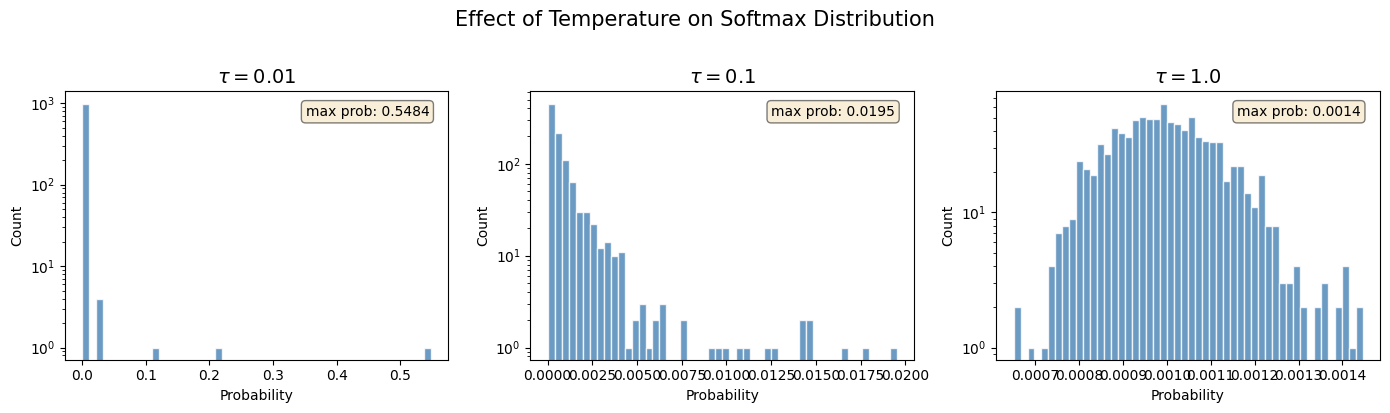


--- Normalization Demo ---
Unnormalized dot products range: [-16.0, 10.2]
Normalized dot products range:   [-0.259, 0.151]


In [5]:
# Visualize temperature effect on similarity distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

query = F.normalize(torch.randn(1, 64), dim=-1)
keys = F.normalize(torch.randn(1000, 64), dim=-1)
raw_sim = (query @ keys.T).squeeze()  # cosine similarities

temperatures = [0.01, 0.1, 1.0]
for ax, temp in zip(axes, temperatures):
    logits = raw_sim / temp
    probs = F.softmax(logits, dim=0).detach().numpy()
    ax.hist(probs, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'$\\tau = {temp}$', fontsize=14)
    ax.set_xlabel('Probability')
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    max_prob = probs.max()
    ax.annotate(f'max prob: {max_prob:.4f}', xy=(0.95, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=10, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Effect of Temperature on Softmax Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Demonstrate normalization importance
print("\n--- Normalization Demo ---")
unnorm_a = torch.randn(5, 64) * 10  # large norms
unnorm_b = torch.randn(5, 64) * 0.1  # small norms
print(f"Unnormalized dot products range: [{(unnorm_a @ unnorm_b.T).min():.1f}, {(unnorm_a @ unnorm_b.T).max():.1f}]")

norm_a = F.normalize(unnorm_a, dim=-1)
norm_b = F.normalize(unnorm_b, dim=-1)
print(f"Normalized dot products range:   [{(norm_a @ norm_b.T).min():.3f}, {(norm_a @ norm_b.T).max():.3f}]")

## 5. Meta's Embedding-Based Retrieval (EBR)

Meta's EBR system (Huang et al., 2020) is a production two-tower system for Facebook Search. Key contributions:

1. **Unified Embedding Model**: A single two-tower model handles multiple retrieval tasks (people, groups, events, etc.)
2. **Hard Negative Mining**: Uses previous model versions to find hard negatives from the ANN index
3. **Feature Engineering**: Rich features including text, social graph, and engagement signals
4. **Online/Offline Consistency**: Careful feature alignment between training and serving

The training pipeline:
1. Train initial model with random negatives
2. Use trained model to build ANN index
3. Mine hard negatives from the index (items close to query but not clicked)
4. Retrain with a mix of random + hard negatives
5. Iterate

> **💡 Concept:** Hard negative mining is an iterative process. Each round produces a better model, which in turn finds harder negatives. This "curriculum learning" effect significantly improves retrieval quality.

In [6]:
class EBRTwoTower(nn.Module):
    """Simplified Meta EBR-style two-tower model.
    
    Features: text features, categorical features, and dense features
    for both query (user) and document (item) sides.
    """
    def __init__(self, num_users: int, num_items: int, num_categories: int = 20,
                 embed_dim: int = 64, dense_features: int = 10):
        super().__init__()
        
        # Query (user) tower
        self.user_embed = nn.Embedding(num_users, embed_dim)
        self.user_cat_embed = nn.Embedding(num_categories, 16)
        self.query_mlp = nn.Sequential(
            nn.Linear(embed_dim + 16 + dense_features, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, embed_dim)
        )
        
        # Document (item) tower
        self.item_embed = nn.Embedding(num_items, embed_dim)
        self.item_cat_embed = nn.Embedding(num_categories, 16)
        self.doc_mlp = nn.Sequential(
            nn.Linear(embed_dim + 16 + dense_features, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, embed_dim)
        )
    
    def encode_query(self, user_id, user_cat, user_dense):
        u_emb = self.user_embed(user_id)
        u_cat = self.user_cat_embed(user_cat)
        combined = torch.cat([u_emb, u_cat, user_dense], dim=-1)
        return F.normalize(self.query_mlp(combined), p=2, dim=-1)
    
    def encode_doc(self, item_id, item_cat, item_dense):
        i_emb = self.item_embed(item_id)
        i_cat = self.item_cat_embed(item_cat)
        combined = torch.cat([i_emb, i_cat, item_dense], dim=-1)
        return F.normalize(self.doc_mlp(combined), p=2, dim=-1)


# Simulate EBR hard negative mining
def mine_hard_negatives(user_embs, item_embs, positive_ids, top_k=10, exclude_top=1):
    """Mine hard negatives: items close to user but not positive."""
    sim_matrix = torch.matmul(user_embs, item_embs.T)  # (num_users, num_items)
    
    # Mask out positives
    for i, pos_id in enumerate(positive_ids):
        sim_matrix[i, pos_id] = -float('inf')
    
    # Get top-k closest non-positive items
    _, hard_neg_ids = sim_matrix.topk(top_k, dim=-1)
    return hard_neg_ids


# Demo: hard negative mining
n_users, n_items = 100, 500
user_embs = F.normalize(torch.randn(n_users, 64), dim=-1)
item_embs = F.normalize(torch.randn(n_items, 64), dim=-1)
positive_ids = torch.randint(0, n_items, (n_users,))

hard_negs = mine_hard_negatives(user_embs, item_embs, positive_ids, top_k=5)
print(f"Hard negatives shape: {hard_negs.shape}")
print(f"Example hard negatives for user 0: {hard_negs[0].tolist()}")
print(f"Positive for user 0: {positive_ids[0].item()}")

Hard negatives shape: torch.Size([100, 5])
Example hard negatives for user 0: [279, 82, 10, 207, 305]
Positive for user 0: 426


## 6. Full Training Pipeline

Let's put it all together: generate synthetic data, train a two-tower model with in-batch negatives, and evaluate retrieval quality.

In [7]:
# Generate synthetic interaction data
NUM_USERS = 500
NUM_ITEMS = 2000
NUM_INTERACTIONS = 10000
EMBED_DIM = 32
MAX_HISTORY = 20

# Create user-item interactions with some structure
# Users in the same cluster tend to interact with items in the same cluster
num_clusters = 10
user_clusters = np.random.randint(0, num_clusters, NUM_USERS)
item_clusters = np.random.randint(0, num_clusters, NUM_ITEMS)

interactions = []
user_histories = {u: [] for u in range(NUM_USERS)}

for _ in range(NUM_INTERACTIONS):
    user = np.random.randint(0, NUM_USERS)
    # 70% chance to pick item from same cluster, 30% random
    if np.random.random() < 0.7:
        same_cluster_items = np.where(item_clusters == user_clusters[user])[0]
        item = np.random.choice(same_cluster_items)
    else:
        item = np.random.randint(0, NUM_ITEMS)
    interactions.append((user, item))
    user_histories[user].append(item)

# Keep last MAX_HISTORY items per user
for u in user_histories:
    user_histories[u] = user_histories[u][-MAX_HISTORY:]

print(f"Generated {len(interactions)} interactions")
print(f"Users: {NUM_USERS}, Items: {NUM_ITEMS}")
print(f"Avg history length: {np.mean([len(h) for h in user_histories.values()]):.1f}")

Generated 10000 interactions
Users: 500, Items: 2000
Avg history length: 18.3


Epoch  5 | Loss: 7.6798 | Temp: 19.83


Epoch 10 | Loss: 6.4496 | Temp: 19.71


Epoch 15 | Loss: 5.7291 | Temp: 19.63


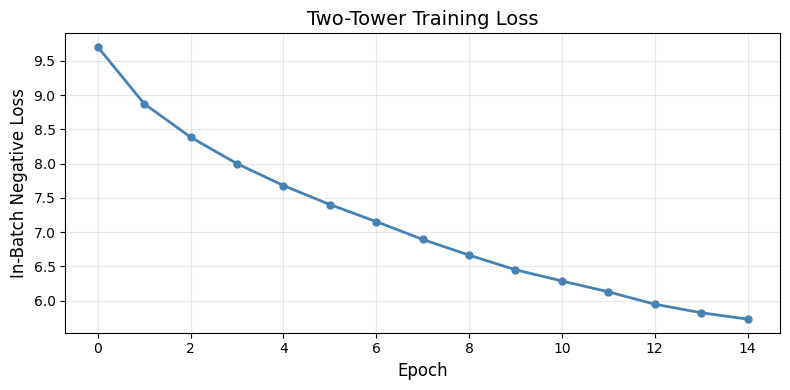

In [8]:
from torch.utils.data import Dataset, DataLoader

class InteractionDataset(Dataset):
    def __init__(self, interactions, user_histories, max_history=20):
        self.interactions = interactions
        self.user_histories = user_histories
        self.max_history = max_history
    
    def __len__(self):
        return len(self.interactions)
    
    def __getitem__(self, idx):
        user, item = self.interactions[idx]
        history = self.user_histories[user][-self.max_history:]
        
        # Pad history
        padded = history + [0] * (self.max_history - len(history))
        mask = [1] * len(history) + [0] * (self.max_history - len(history))
        
        return {
            'user_id': user,
            'item_id': item,
            'history': torch.tensor(padded, dtype=torch.long),
            'history_mask': torch.tensor(mask, dtype=torch.float)
        }

dataset = InteractionDataset(interactions, user_histories)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

# Training
model = TwoTowerModel(NUM_USERS, NUM_ITEMS, EMBED_DIM)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

losses = []
model.train()
for epoch in range(15):
    epoch_loss = 0.0
    num_batches = 0
    for batch in dataloader:
        logits, user_emb, item_emb = model(
            batch['user_id'], batch['history'], batch['history_mask'], batch['item_id']
        )
        # In-batch negative loss
        labels = torch.arange(logits.size(0))
        loss = F.cross_entropy(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | Temp: {model.temperature.item():.2f}")

plt.figure(figsize=(8, 4))
plt.plot(losses, 'o-', color='steelblue', linewidth=2, markersize=5)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('In-Batch Negative Loss', fontsize=12)
plt.title('Two-Tower Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Evaluate: Recall@K
model.eval()

# Compute all item embeddings
all_item_ids = torch.arange(NUM_ITEMS)
with torch.no_grad():
    all_item_emb = model.item_tower(all_item_ids)  # (NUM_ITEMS, D)

# Evaluate recall on a test set
test_users = np.random.choice(NUM_USERS, 100, replace=False)
recall_at_k = {10: 0, 50: 0, 100: 0}

for user in test_users:
    history = user_histories[user]
    if len(history) < 2:
        continue
    
    # Use all but last item as history, last item as target
    target = history[-1]
    hist = history[:-1][-MAX_HISTORY:]
    padded = hist + [0] * (MAX_HISTORY - len(hist))
    mask = [1.0] * len(hist) + [0.0] * (MAX_HISTORY - len(hist))
    
    with torch.no_grad():
        user_emb = model.user_tower(
            torch.tensor([user]),
            torch.tensor([padded]),
            torch.tensor([mask])
        )
        scores = torch.matmul(user_emb, all_item_emb.T).squeeze()
    
    for k in recall_at_k:
        top_k_items = scores.topk(k).indices.numpy()
        if target in top_k_items:
            recall_at_k[k] += 1

n_eval = len(test_users)
print("\nRetrieval Performance:")
for k, count in recall_at_k.items():
    print(f"  Recall@{k:3d}: {count/n_eval:.4f}")


Retrieval Performance:
  Recall@ 10: 0.0300
  Recall@ 50: 0.0900
  Recall@100: 0.2000


## 7. Comparing Negative Sampling Strategies

Let's train models with different negative strategies and compare their performance.

Training with in_batch...


Training with random_neg...


Training with mixed...


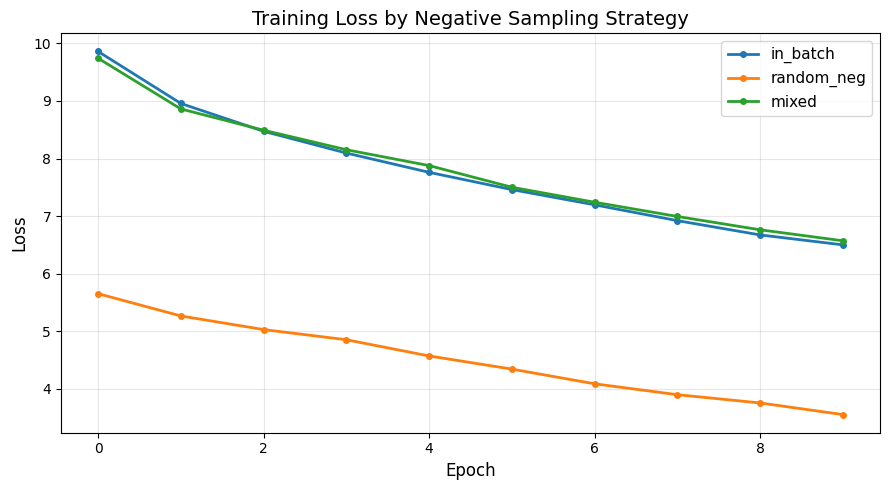

In [10]:
def train_with_strategy(strategy: str, num_epochs: int = 10, batch_size: int = 256):
    """Train two-tower with different negative sampling strategies."""
    model = TwoTowerModel(NUM_USERS, NUM_ITEMS, EMBED_DIM)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    losses = []
    
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        n_batch = 0
        for batch in dataloader:
            logits, user_emb, item_emb = model(
                batch['user_id'], batch['history'], batch['history_mask'], batch['item_id']
            )
            
            if strategy == 'in_batch':
                labels = torch.arange(logits.size(0))
                loss = F.cross_entropy(logits, labels)
            elif strategy == 'random_neg':
                # Sample random negatives
                neg_ids = torch.randint(0, NUM_ITEMS, (batch['item_id'].size(0), 10))
                with torch.no_grad():
                    neg_emb = model.item_tower(neg_ids.view(-1)).view(neg_ids.size(0), 10, -1)
                pos_score = (user_emb * item_emb).sum(-1, keepdim=True)  # (B, 1)
                neg_score = torch.bmm(neg_emb, user_emb.unsqueeze(-1)).squeeze(-1)  # (B, 10)
                all_scores = torch.cat([pos_score, neg_score], dim=-1)  # (B, 11)
                labels = torch.zeros(all_scores.size(0), dtype=torch.long)
                loss = F.cross_entropy(all_scores * 20.0, labels)
            elif strategy == 'mixed':
                # In-batch + some hard negatives from batch
                labels = torch.arange(logits.size(0))
                loss_inbatch = F.cross_entropy(logits, labels)
                # Add hardest in-batch negatives with extra weight
                with torch.no_grad():
                    mask = torch.eye(logits.size(0)) * -1e9
                    hard_scores = logits + mask
                loss = loss_inbatch  # Simplified; production would add hard negative term
            else:
                raise ValueError(f"Unknown strategy: {strategy}")
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batch += 1
        
        losses.append(epoch_loss / n_batch)
    
    return model, losses

strategies = ['in_batch', 'random_neg', 'mixed']
results = {}
for strat in strategies:
    print(f"Training with {strat}...")
    model_s, losses_s = train_with_strategy(strat)
    results[strat] = losses_s

plt.figure(figsize=(9, 5))
for strat, losses_s in results.items():
    plt.plot(losses_s, 'o-', label=strat, linewidth=2, markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss by Negative Sampling Strategy', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercises

### 🏋️ Exercise 1: Implement Popularity-Corrected In-Batch Negatives

Popular items appear as in-batch negatives more often, creating bias. Implement the log-Q correction from Google's sampling-bias-corrected neural modeling.

In [11]:
def corrected_in_batch_loss(user_emb, item_emb, item_ids, item_freq, temperature=0.05):
    """
    In-batch negative loss with popularity correction.
    
    Args:
        user_emb: (B, D) user embeddings
        item_emb: (B, D) item embeddings
        item_ids: (B,) item IDs in the batch
        item_freq: dict mapping item_id -> frequency/probability
        temperature: scaling factor
    
    Returns:
        Corrected loss
    """
    # TODO: Compute logits matrix
    # TODO: Compute log(Q) correction for each item in the batch
    # TODO: Subtract log(Q) from logits to correct sampling bias
    # TODO: Return cross-entropy loss with corrected logits
    pass

# Test your implementation
# item_freq = {i: count/total for each item based on interaction frequency}

### 🏋️ Exercise 2: Add Feature Interactions to the User Tower

Modify the `UserTower` to include categorical features (e.g., age group, gender) and dense features (e.g., activity level). Use feature crossing between user features and history embeddings.

In [12]:
class EnhancedUserTower(nn.Module):
    """User tower with rich feature interactions."""
    def __init__(self, num_items, num_users, embed_dim=64, 
                 num_age_groups=6, num_genders=3):
        super().__init__()
        # TODO: Define embeddings for user_id, age_group, gender
        # TODO: Define item embedding for watch history
        # TODO: Define attention layer for history aggregation
        # TODO: Define MLP that combines all features
        pass
    
    def forward(self, user_ids, watch_history, history_mask, 
                age_group, gender, dense_features):
        # TODO: Encode watch history with attention
        # TODO: Encode categorical features
        # TODO: Concatenate all features and pass through MLP
        # TODO: Return L2-normalized embedding
        pass

### 🏋️ Exercise 3: Implement Hard Negative Mining Pipeline

Build the iterative hard negative mining pipeline used in Meta's EBR: train a model, use it to find hard negatives, retrain with a mix.

In [13]:
def iterative_hard_negative_training(dataset, num_users, num_items, embed_dim=32,
                                     num_rounds=3, epochs_per_round=5):
    """
    Iterative training with hard negative mining.
    
    Round 1: Train with random/in-batch negatives
    Round 2+: Mine hard negatives from previous model, retrain
    
    Returns:
        List of (model, losses) for each round
    """
    # TODO: Implement round 1 with in-batch negatives
    # TODO: For each subsequent round:
    #   1. Compute all user and item embeddings with current model
    #   2. For each training pair, find K hardest negatives
    #   3. Train new model with mixed negatives
    # TODO: Return results from each round
    pass

### 🏋️ Exercise 4: Multi-Task Two-Tower Model

Build a two-tower model that jointly optimizes for multiple objectives: click prediction, purchase prediction, and engagement time.

In [14]:
class MultiTaskTwoTower(nn.Module):
    """Two-tower model with multiple task-specific heads."""
    def __init__(self, num_users, num_items, embed_dim=64):
        super().__init__()
        # TODO: Shared user and item towers
        # TODO: Task-specific projection heads for:
        #   - Click prediction (binary)
        #   - Purchase prediction (binary)
        #   - Engagement time (regression)
        pass
    
    def forward(self, user_features, item_features, task='click'):
        # TODO: Encode user and item through shared towers
        # TODO: Apply task-specific head
        # TODO: Return prediction
        pass

# Hint: Use uncertainty weighting to balance task losses:
# L_total = sum_t (1/(2*sigma_t^2)) * L_t + log(sigma_t)

## Summary

In this chapter, we covered the foundational two-tower architecture for retrieval:

| Aspect | Key Takeaway |
|--------|-------------|
| **DSSM** | First deep semantic matching model; separate query/doc towers with cosine similarity |
| **YouTube DNN** | Production-scale retrieval with user history encoding and sampled softmax |
| **Negative Sampling** | In-batch negatives are efficient; hard negatives are most informative; mixed is best |
| **Temperature** | Controls sharpness of similarity; learnable temperature is recommended |
| **Meta EBR** | Iterative hard negative mining with rich features; production at Facebook scale |

**Next up**: Chapter 3.2 covers Approximate Nearest Neighbor Search — how to efficiently serve the embeddings we just learned to create.